# Policy Comparison

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from battery_sim.battery.battery import Battery
from battery_sim.agents.policies.rule_based import ThresholdPolicy
from battery_sim.agents.policies.median_threshold import (
    MedianThresholdPolicy,
    ProbabilisticMedianThresholdPolicy,
)
from battery_sim.agents.policies.continuous_probabilistic import ContinuousProbabilisticPolicy
from battery_sim.agents.policies.forecast_lp import ForecastLPPolicy
from battery_sim.agents.policies.mppi import MPPIPolicy
from battery_sim.agents.policies.oracle import OraclePolicy
from battery_sim.models.median_reversion import MedianReversionModel
from battery_sim.optimization.policy_optimizer import evaluate_full
from battery_sim.utils.types import EvalResult
from battery_sim.utils.plotting import plot_eval, plot_hourly_profile, compare_policies, compare_policies_multi

In [2]:
# Load data
train_df = pd.read_csv('../data/NEM_NSW1_2025-01-01_2025-12-31_1h.csv')
test_df = pd.read_csv('../data/NEM_NSW1_2026-01-01_2026-03-01_1h.csv')

print(f'Train: {len(train_df)} rows ({train_df.iloc[0, 0]} to {train_df.iloc[-1, 0]})')
print(f'Test:  {len(test_df)} rows ({test_df.iloc[0, 0]} to {test_df.iloc[-1, 0]})')

Train: 8736 rows (2025-01-01 10:00:00 to 2025-12-31 09:00:00)
Test:  1416 rows (2026-01-01 10:00:00 to 2026-03-01 09:00:00)


## Price Data Overview

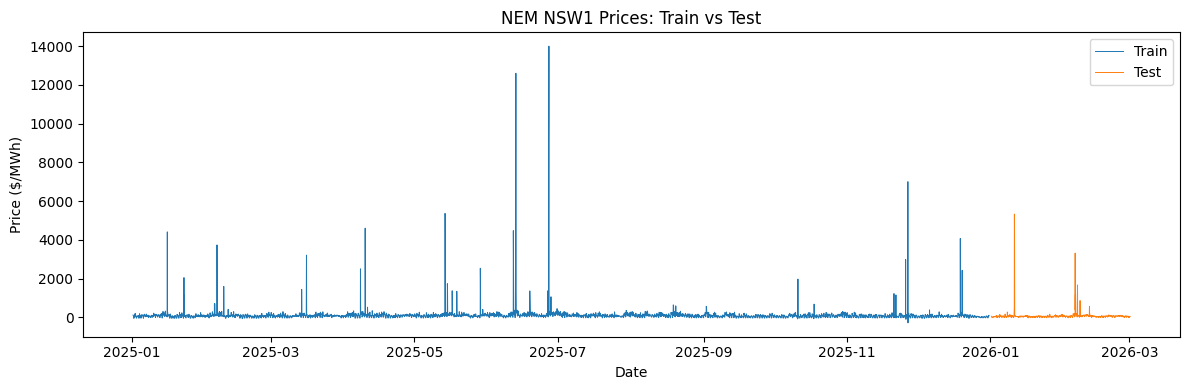

In [20]:
train_ts = pd.to_datetime(train_df['timestamp'])
test_ts = pd.to_datetime(test_df['timestamp'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_ts, train_df['price'], color='tab:blue', lw=0.7, label='Train')
ax.plot(test_ts, test_df['price'], color='tab:orange', lw=0.7, label='Test')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/MWh)')
ax.set_title('NEM NSW1 Prices: Train vs Test')
ax.legend()
fig.tight_layout()
plt.show()

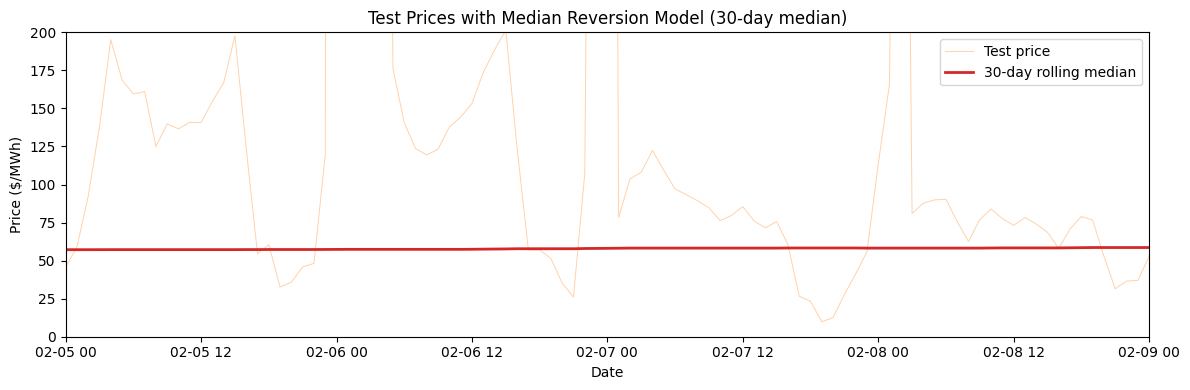

In [38]:
overview_model = MedianReversionModel(window_days=30, interval_minutes=60)
overview_model.fit(train_df)

# Stream test prices through the fitted model and record the 30-day rolling median
medians = []
for p in test_df['price'].values:
    overview_model.update(float(p))
    medians.append(overview_model.rolling_median)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_ts, test_df['price'], color='tab:orange', lw=0.7, alpha=0.35, label='Test price')
ax.plot(test_ts, medians, color='tab:red', lw=2.0, label='30-day rolling median')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/MWh)')
ax.set_title('Test Prices with Median Reversion Model (30-day median)')
ax.legend()
ax.set_xlim(pd.Timestamp('2026-02-05'), pd.Timestamp('2026-02-09'))
ax.set_ylim(0, 200)
fig.tight_layout()
plt.show()

In [ ]:
# Battery config
# capacity is 200.0 mwh, charge rate is 100mw per hour
# very roughly based on New England 1 in NSW: https://gateway.icn.org.au/projects/14788/pg-14788
battery = Battery(
    capacity_mwh=200.0,
    max_charge_rate_mw=100,
    max_discharge_rate_mw=100,
    efficiency=0.9,
)

In [4]:
# Data-driven price grid for threshold-based policies (ThresholdPolicy, ContinuousProbabilisticPolicy)
Q = 20
vals = np.quantile(train_df.price, q=[i / Q for i in range(1, Q)])
PRICE_GRID = {
    'buy_threshold': vals,
    'sell_threshold': vals,
}
N_ITERS = 100
WINDOW_LEN = 24

## 1. Deterministic Threshold Policy (no-model baseline)

In [5]:
det_policy = ThresholdPolicy(buy_threshold=50.0, sell_threshold=200.0)
np.random.seed(SEED)
det_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=N_ITERS,
    window_len=WINDOW_LEN,
    param_grid=PRICE_GRID,
)
print(f'Tuned buy_threshold={det_policy.buy_threshold}')
print(f'Tuned sell_threshold={det_policy.sell_threshold}')

Tuned buy_threshold=75.65958325
Tuned sell_threshold=79.847917


## 2. Median Threshold Policy (model point estimate, deterministic)

In [6]:
med_model = MedianReversionModel(window_days=30, interval_minutes=60)
med_policy = MedianThresholdPolicy(model=med_model, buy_dev=25.0, sell_dev=25.0)
np.random.seed(SEED)
med_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=N_ITERS,
    window_len=WINDOW_LEN,
)
print(f'Tuned buy_dev={med_policy.buy_dev}')
print(f'Tuned sell_dev={med_policy.sell_dev}')

Tuned buy_dev=10
Tuned sell_dev=10


## 3. Probabilistic Median Threshold Policy (model + simulation uncertainty)

In [ ]:
prob_med_model = MedianReversionModel(window_days=30, interval_minutes=60)
prob_med_policy = ProbabilisticMedianThresholdPolicy(
    model=prob_med_model,
    buy_dev=25.0,
    sell_dev=25.0,
    horizon=12,
)
np.random.seed(SEED)
prob_med_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=N_ITERS,
    window_len=WINDOW_LEN,
)
print(f'Tuned buy_dev={prob_med_policy.buy_dev}')
print(f'Tuned sell_dev={prob_med_policy.sell_dev}')
print(f'Tuned horizon={prob_med_policy.horizon}')

Tuned buy_dev=10
Tuned sell_dev=10
Tuned horizon=6


## 4. Continuous Probabilistic Policy (model distribution thresholds)

In [8]:
cont_model = MedianReversionModel(window_days=30, interval_minutes=60)
cont_policy = ContinuousProbabilisticPolicy(
    model=cont_model,
    buy_threshold=50.0,
    sell_threshold=200.0,
)
np.random.seed(SEED)
cont_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=N_ITERS,
    window_len=WINDOW_LEN,
    param_grid=PRICE_GRID,
)
print(f'Tuned buy_threshold={cont_policy.buy_threshold}')
print(f'Tuned sell_threshold={cont_policy.sell_threshold}')

Tuned buy_threshold=69.054167
Tuned sell_threshold=79.847917


## 5. Forecast LP Policy (model forecasts + LP optimization)

In [9]:
forecast_lp_model = MedianReversionModel(window_days=30, interval_minutes=60)
forecast_lp_policy = ForecastLPPolicy(
    model=forecast_lp_model,
    battery=battery,
    horizon=12,
    interval_minutes=60,
)

np.random.seed(SEED)
forecast_lp_policy.learn(
    train_data=train_df,
    battery=battery,
)
print("Forecast LP policy trained")

Forecast LP policy trained


## 6. MPPI Policy (model trajectories + path integral)

In [10]:
mppi_model = MedianReversionModel(window_days=30, interval_minutes=60)
mppi_policy = MPPIPolicy(
    model=mppi_model,
    battery=battery,
    horizon=12,
    n_samples=100,
    n_trajectories=100,
)

np.random.seed(SEED)
mppi_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=N_ITERS,
    window_len=WINDOW_LEN,
)
print(f'Tuned noise_sigma: {mppi_policy.noise_sigma}')
print(f'Tuned temperature: {mppi_policy.temperature}')

Tuned noise_sigma: 0.8
Tuned temperature: 5.0


## 7. Oracle (Perfect Foresight Upper Bound)

In [11]:
oracle = OraclePolicy(price_data=test_df, battery=battery)
print(f'Oracle solved LP with {len(test_df) - 1} tradeable steps')

Oracle solved LP with 1415 tradeable steps


## 8. Evaluate on Test Set

In [12]:
N_MPPI_RUNS = 10

# Re-fit models on train data before test evaluation
med_model.fit(train_df)
prob_med_model.fit(train_df)
cont_model.fit(train_df)
forecast_lp_model.fit(train_df)
mppi_model.fit(train_df)

det_eval = evaluate_full('Deterministic Threshold', det_policy, test_df, battery)
med_eval = evaluate_full('Median Threshold', med_policy, test_df, battery)
prob_med_eval = evaluate_full('Probabilistic Median Threshold', prob_med_policy, test_df, battery)
cont_eval = evaluate_full('Continuous Probabilistic', cont_policy, test_df, battery)
forecast_lp_eval = evaluate_full('Forecast LP', forecast_lp_policy, test_df, battery)
oracle_eval = evaluate_full('Oracle', oracle, test_df, battery)

# MPPI: run multiple times, report mean ± std, use mean as main estimate
mppi_runs = [evaluate_full('MPPI', mppi_policy, test_df, battery) for _ in range(N_MPPI_RUNS)]
mppi_revenues = [r.cumulative_revenue for r in mppi_runs]

mean_df = mppi_runs[0].df.copy()
for col in ['action', 'reward', 'soc', 'energy_mwh']:
    mean_df[col] = np.mean([r.df[col].values for r in mppi_runs], axis=0)
mean_df['cumulative_revenue'] = mean_df['reward'].cumsum()
daily = mean_df.set_index('timestamp')['reward'].resample('D').sum()
mppi_eval = EvalResult(
    name='MPPI',
    sim_result=mppi_runs[0].sim_result,
    df=mean_df,
    cumulative_revenue=float(mean_df['cumulative_revenue'].iloc[-1]),
    daily_revenue=daily,
    mean_daily_revenue=float(daily.mean()),
    std_daily_revenue=float(daily.std()),
)

all_evals = [det_eval, med_eval, prob_med_eval, cont_eval, forecast_lp_eval, mppi_eval, oracle_eval]
for e in all_evals:
    print(e.summary())
    print()
print(f'MPPI over {N_MPPI_RUNS} runs: mean=${np.mean(mppi_revenues):,.2f}  std=${np.std(mppi_revenues):,.2f}')

Deterministic Threshold:
  Cumulative revenue: $1,200,237.63
  Mean daily revenue: $20,003.96 (+/- $62,553.68)
  Total steps: 1415

Median Threshold:
  Cumulative revenue: $899,079.01
  Mean daily revenue: $14,984.65 (+/- $32,445.47)
  Total steps: 1415

Probabilistic Median Threshold:
  Cumulative revenue: $919,600.54
  Mean daily revenue: $15,326.68 (+/- $55,748.21)
  Total steps: 1415

Continuous Probabilistic:
  Cumulative revenue: $1,238,593.56
  Mean daily revenue: $20,643.23 (+/- $63,461.35)
  Total steps: 1415

Forecast LP:
  Cumulative revenue: $1,194,120.40
  Mean daily revenue: $19,902.01 (+/- $55,870.01)
  Total steps: 1415

MPPI:
  Cumulative revenue: $931,941.62
  Mean daily revenue: $15,532.36 (+/- $39,967.67)
  Total steps: 1415

Oracle:
  Cumulative revenue: $2,855,468.02
  Mean daily revenue: $47,591.13 (+/- $135,357.34)
  Total steps: 1415

MPPI over 10 runs: mean=$931,941.62  std=$276,299.66


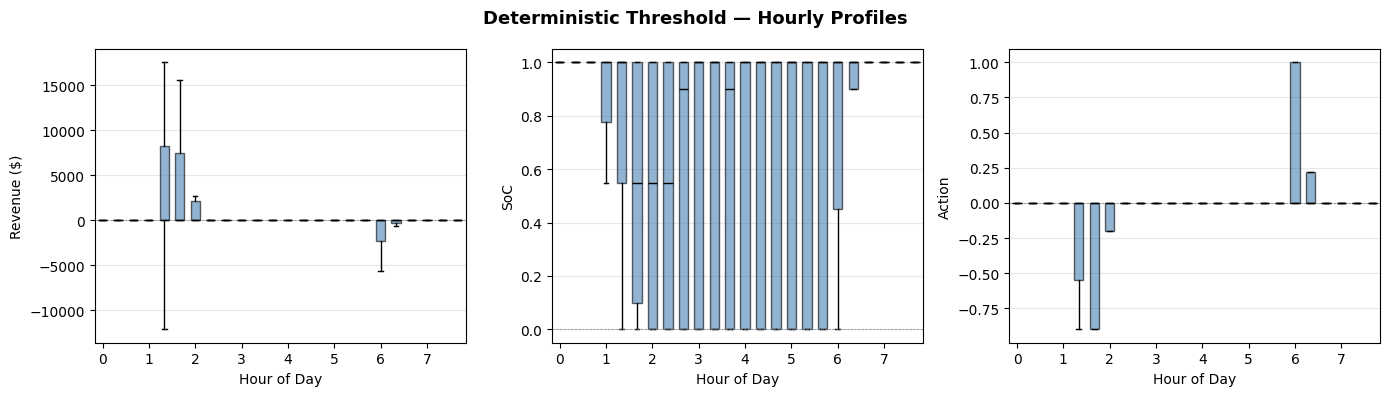

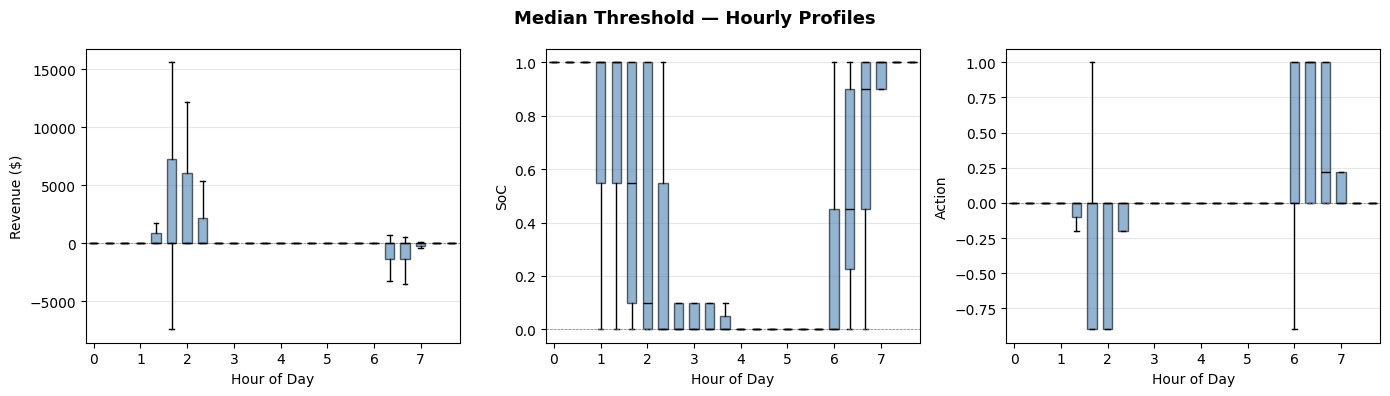

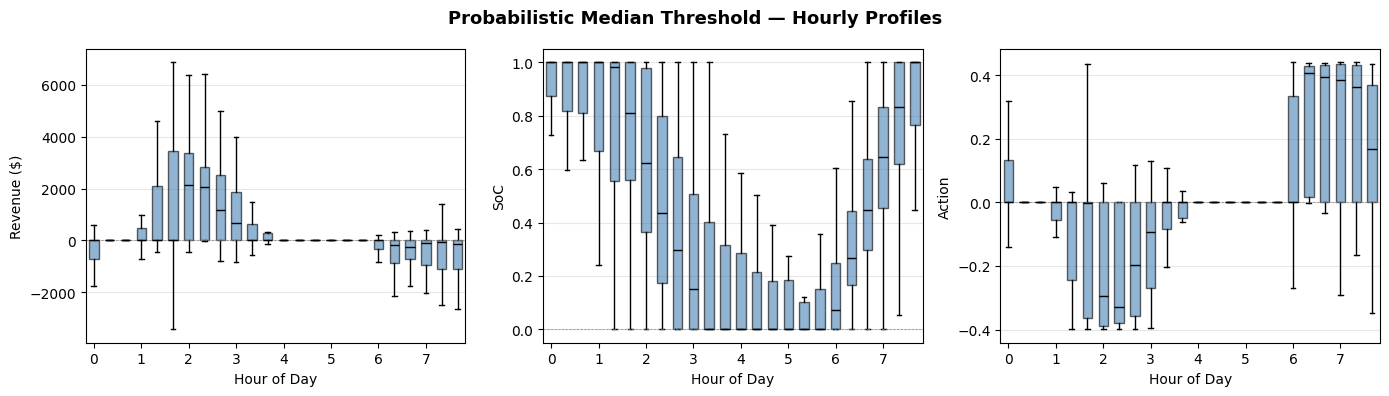

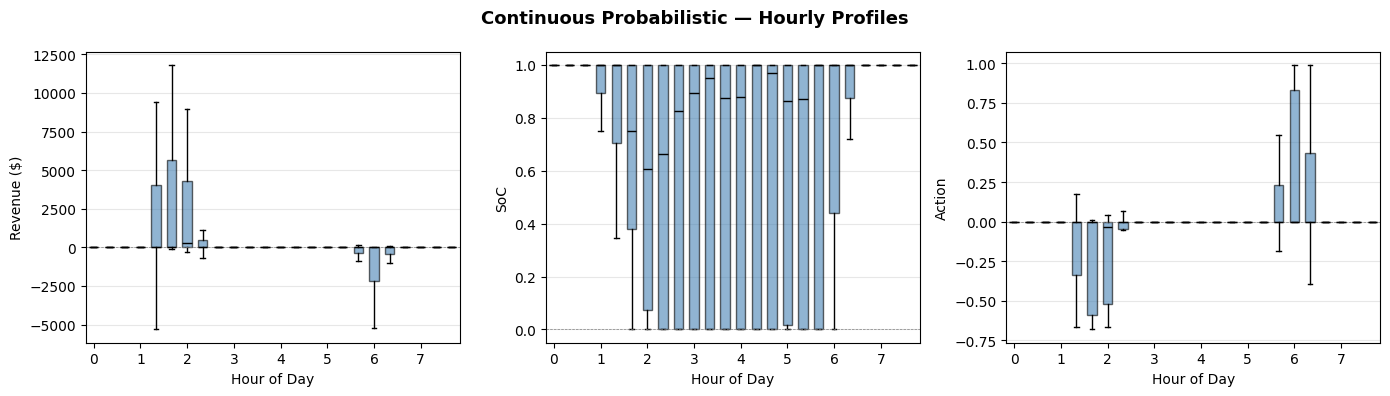

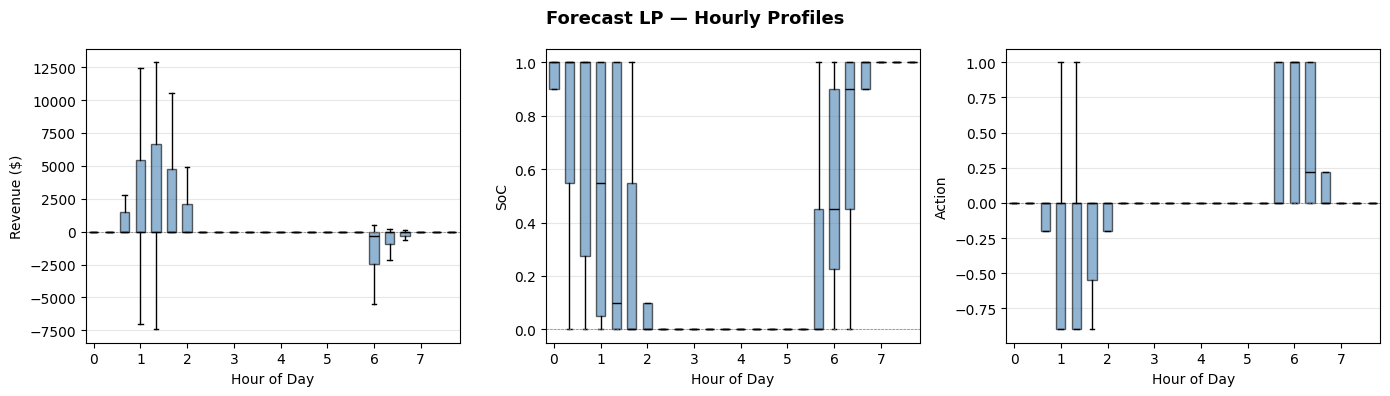

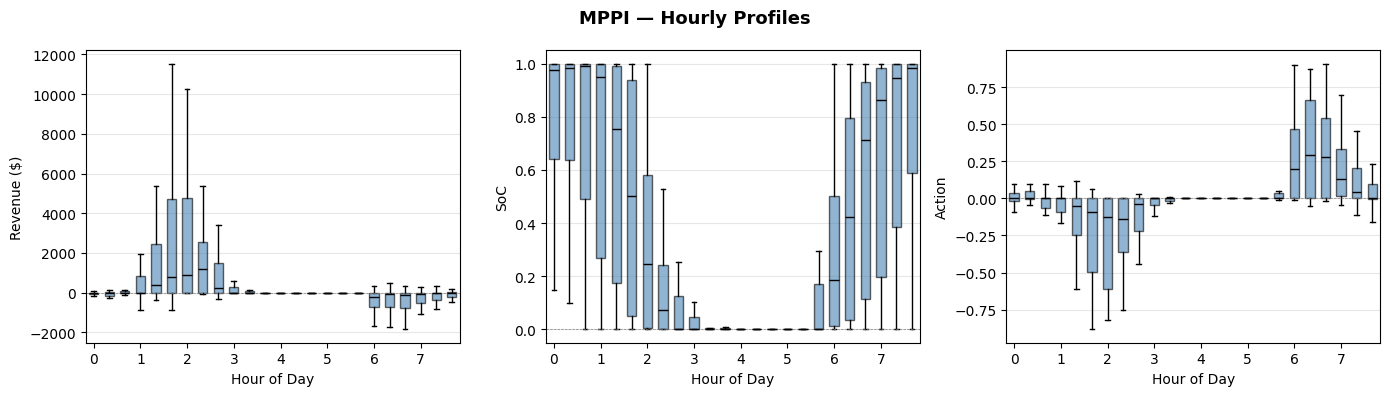

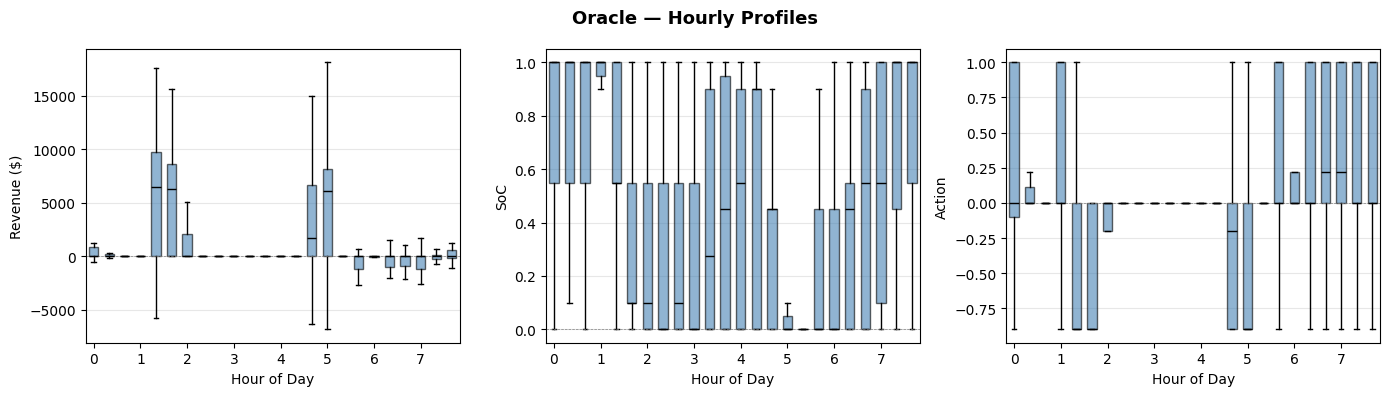

In [13]:
for e in all_evals:
    plot_hourly_profile(e)
    plt.show()

## 10. Detailed Time Series

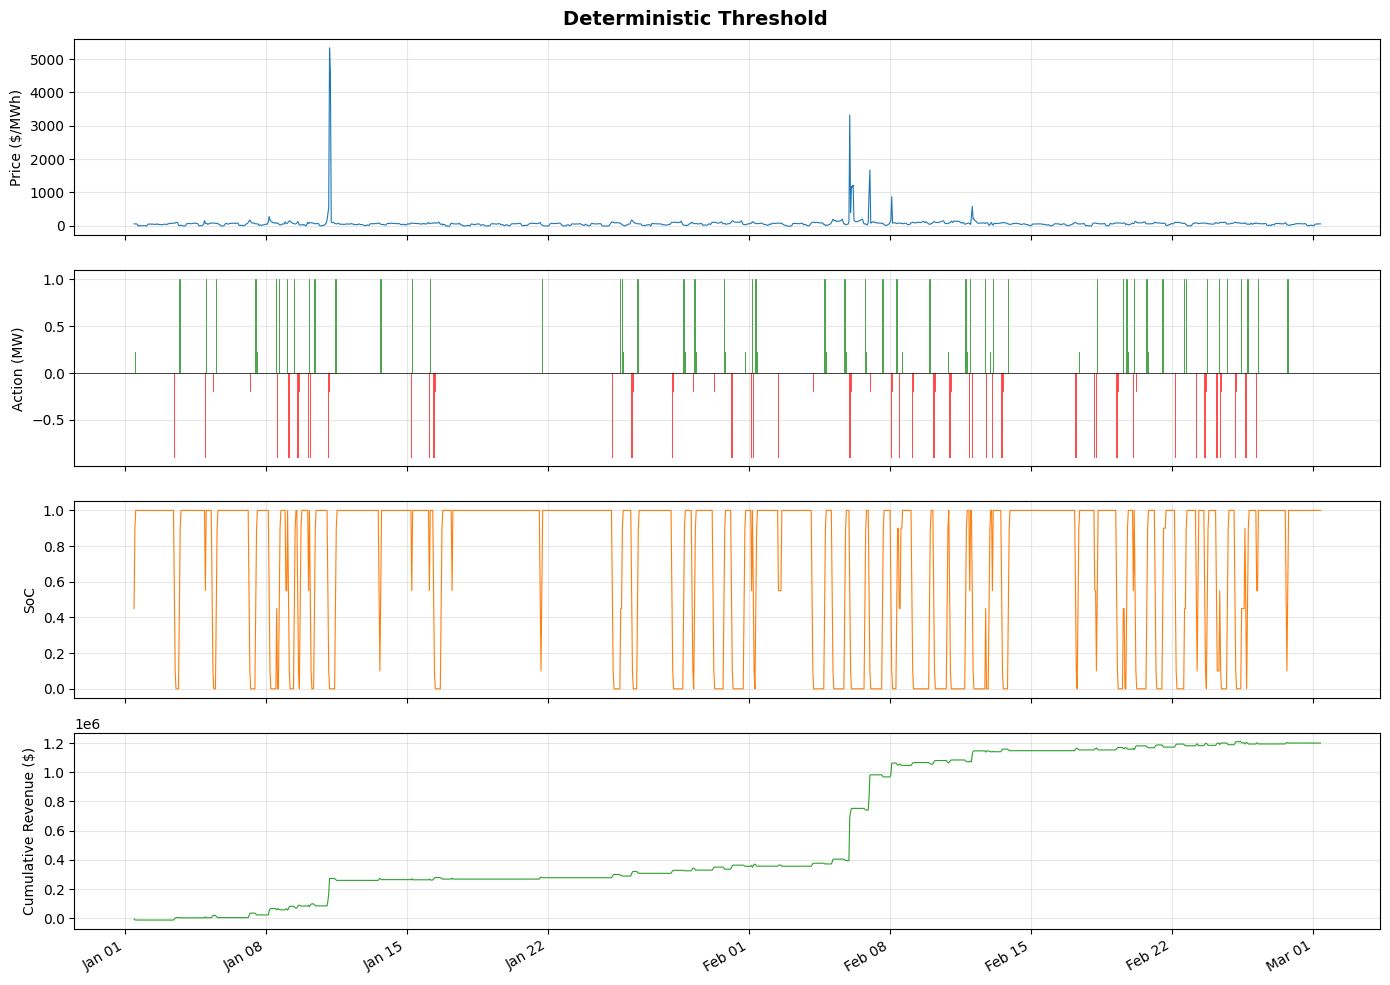

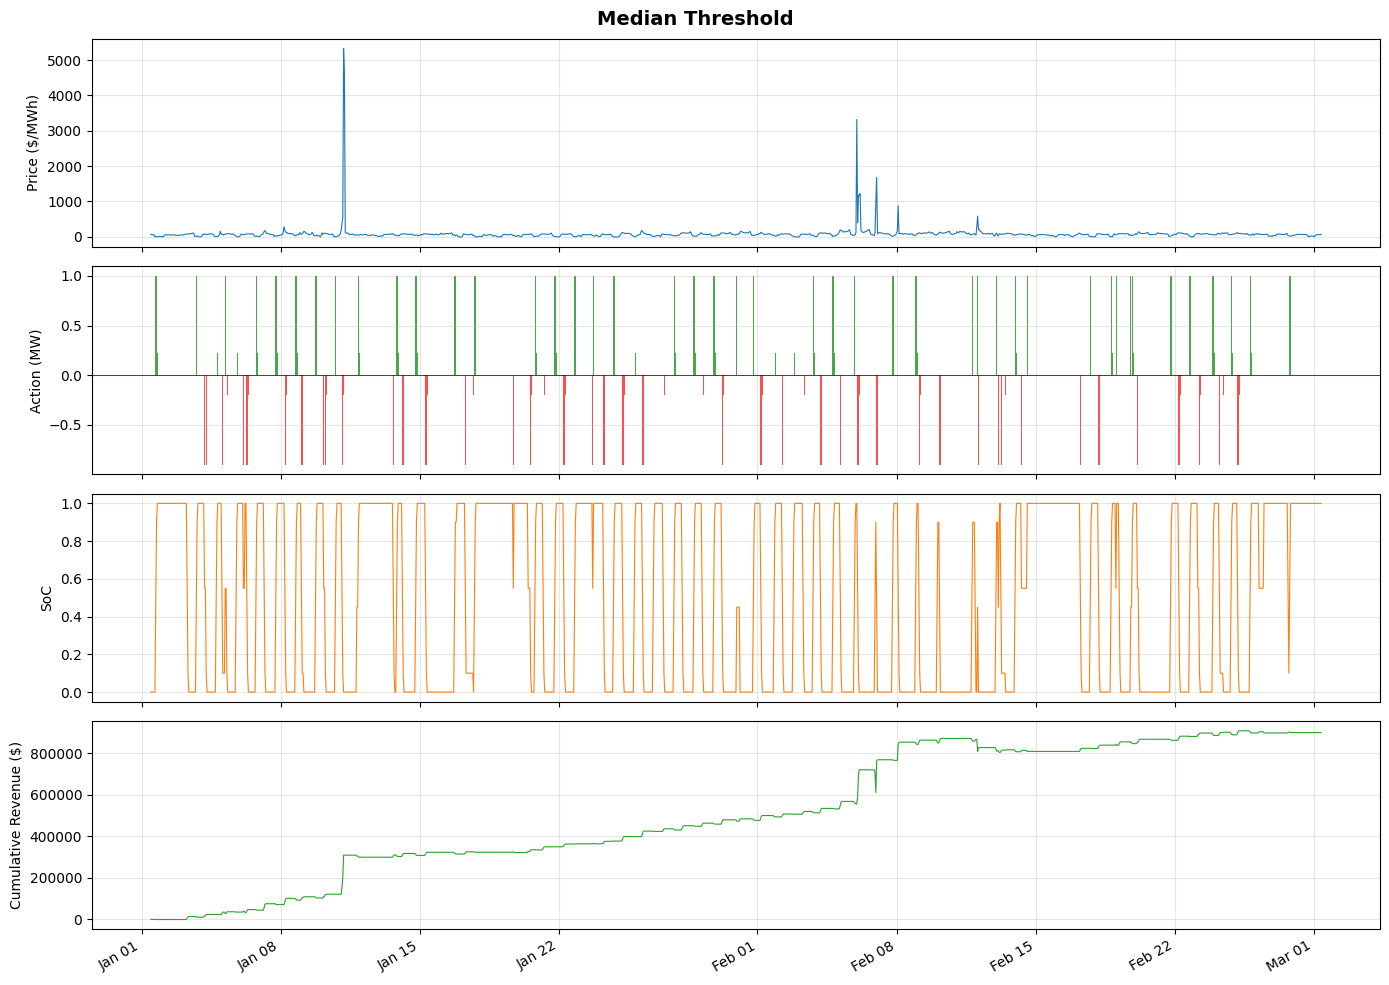

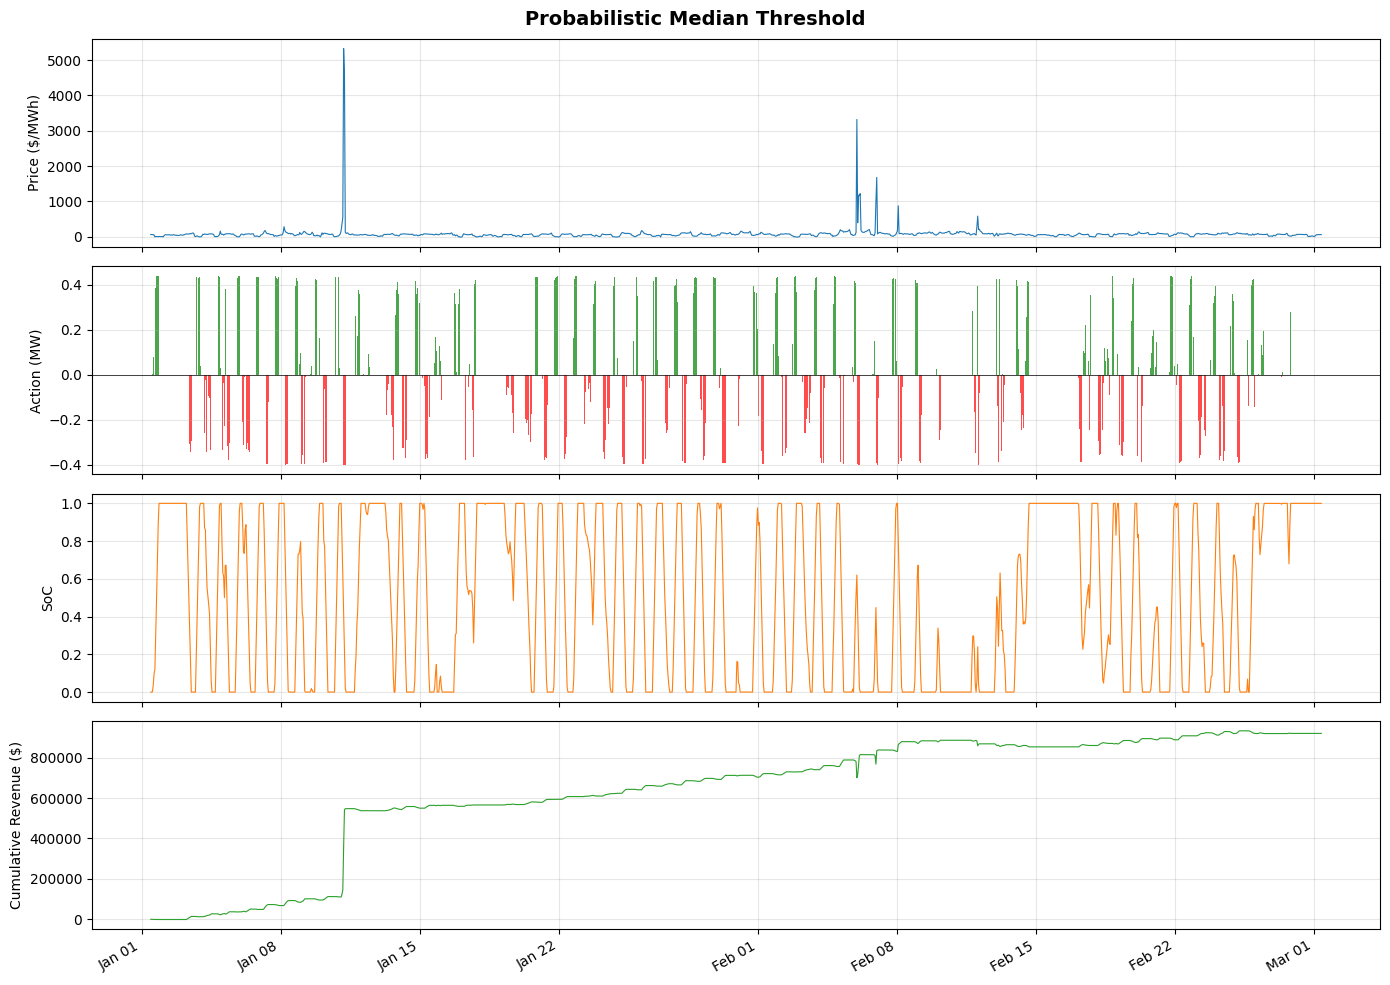

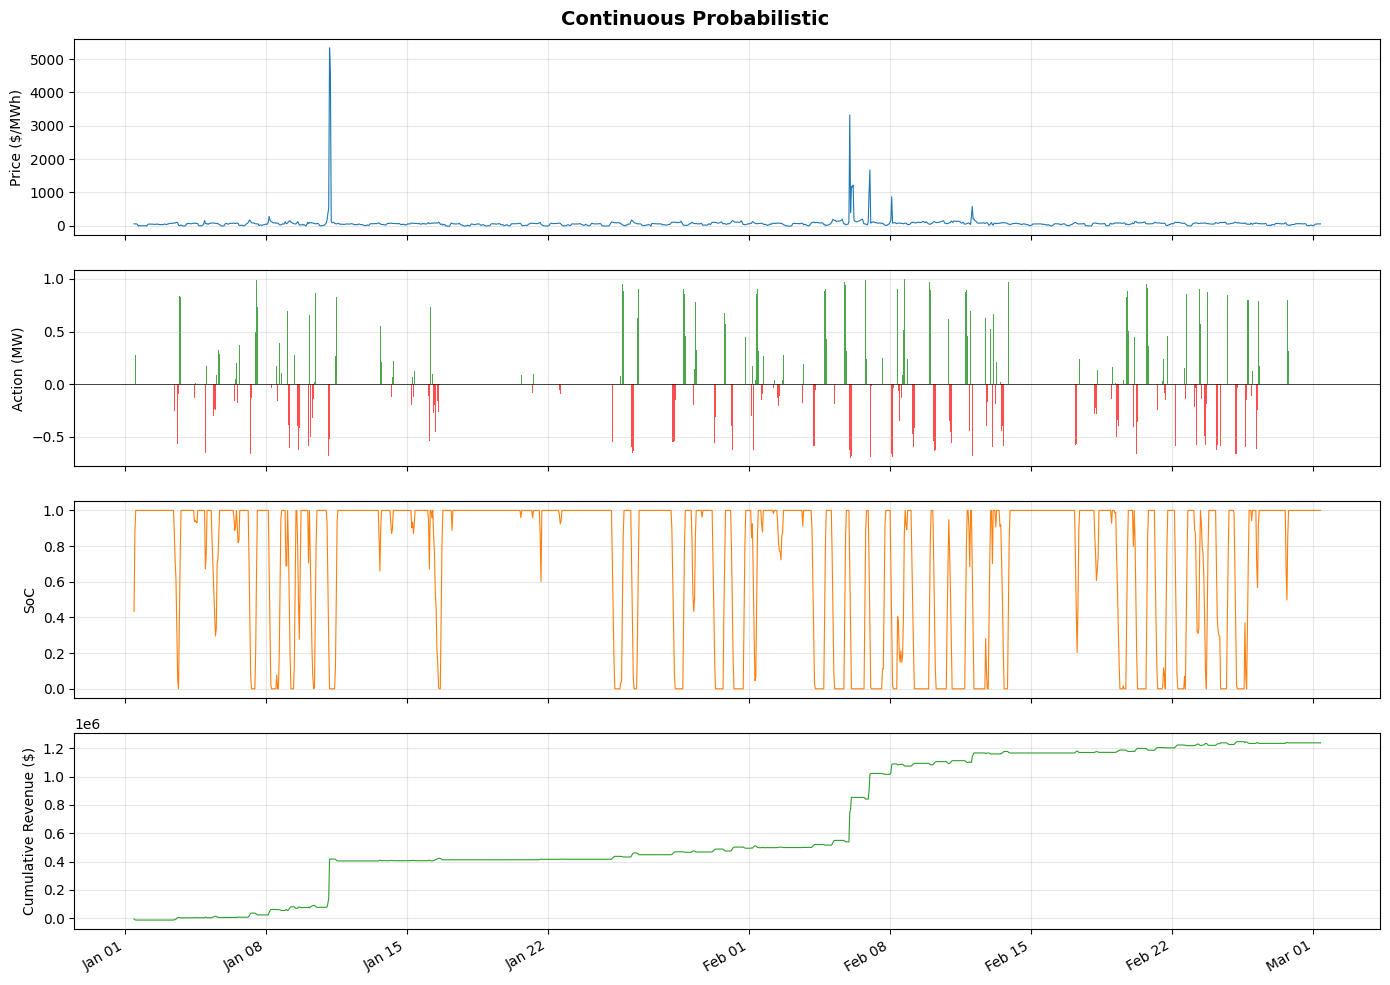

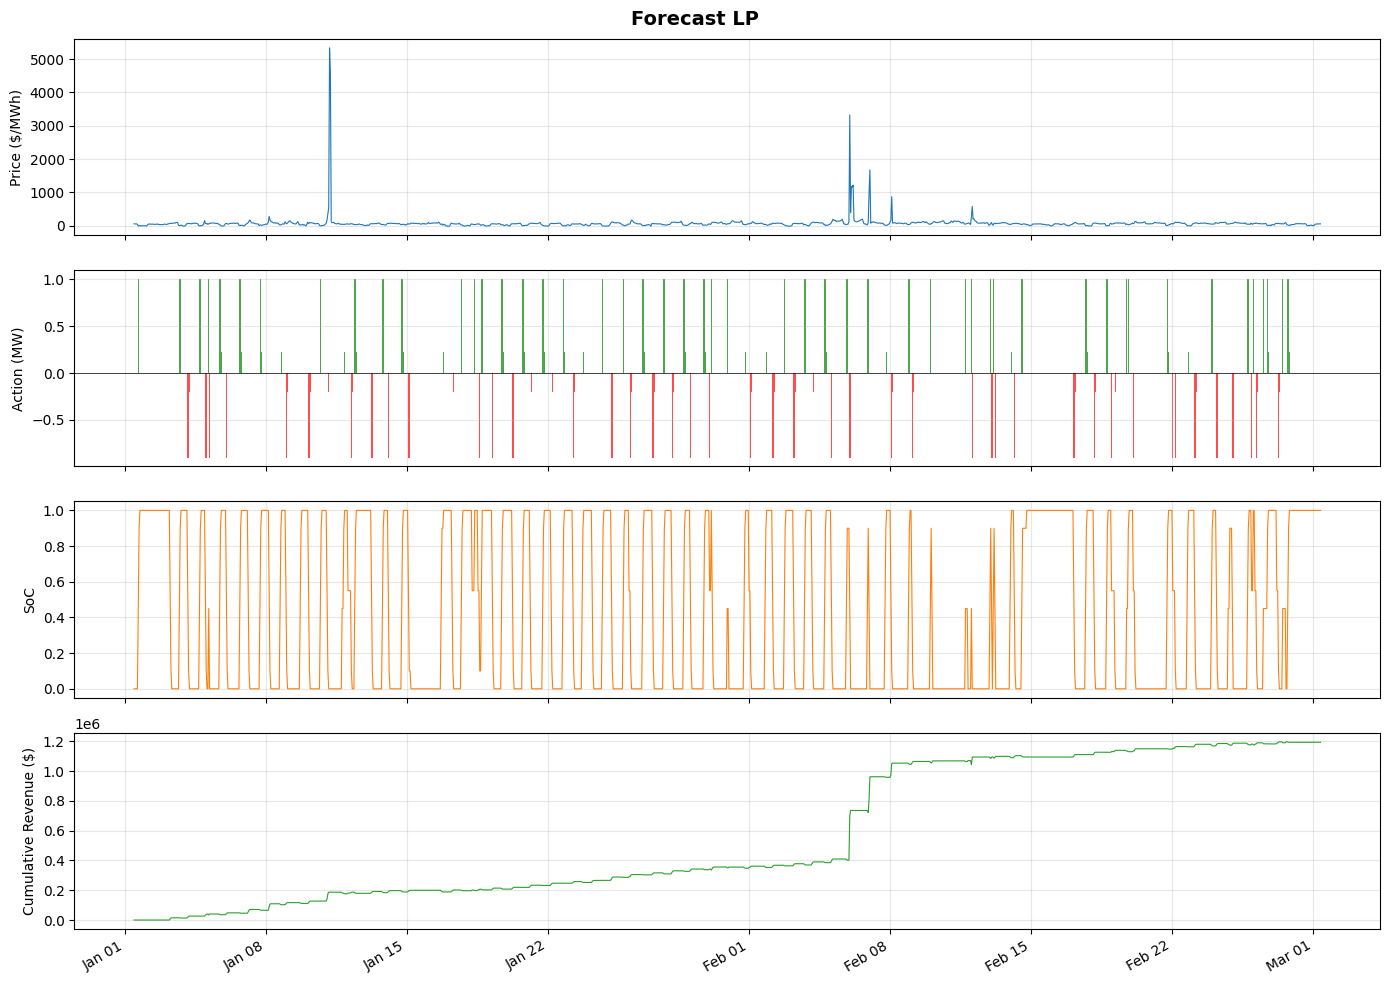

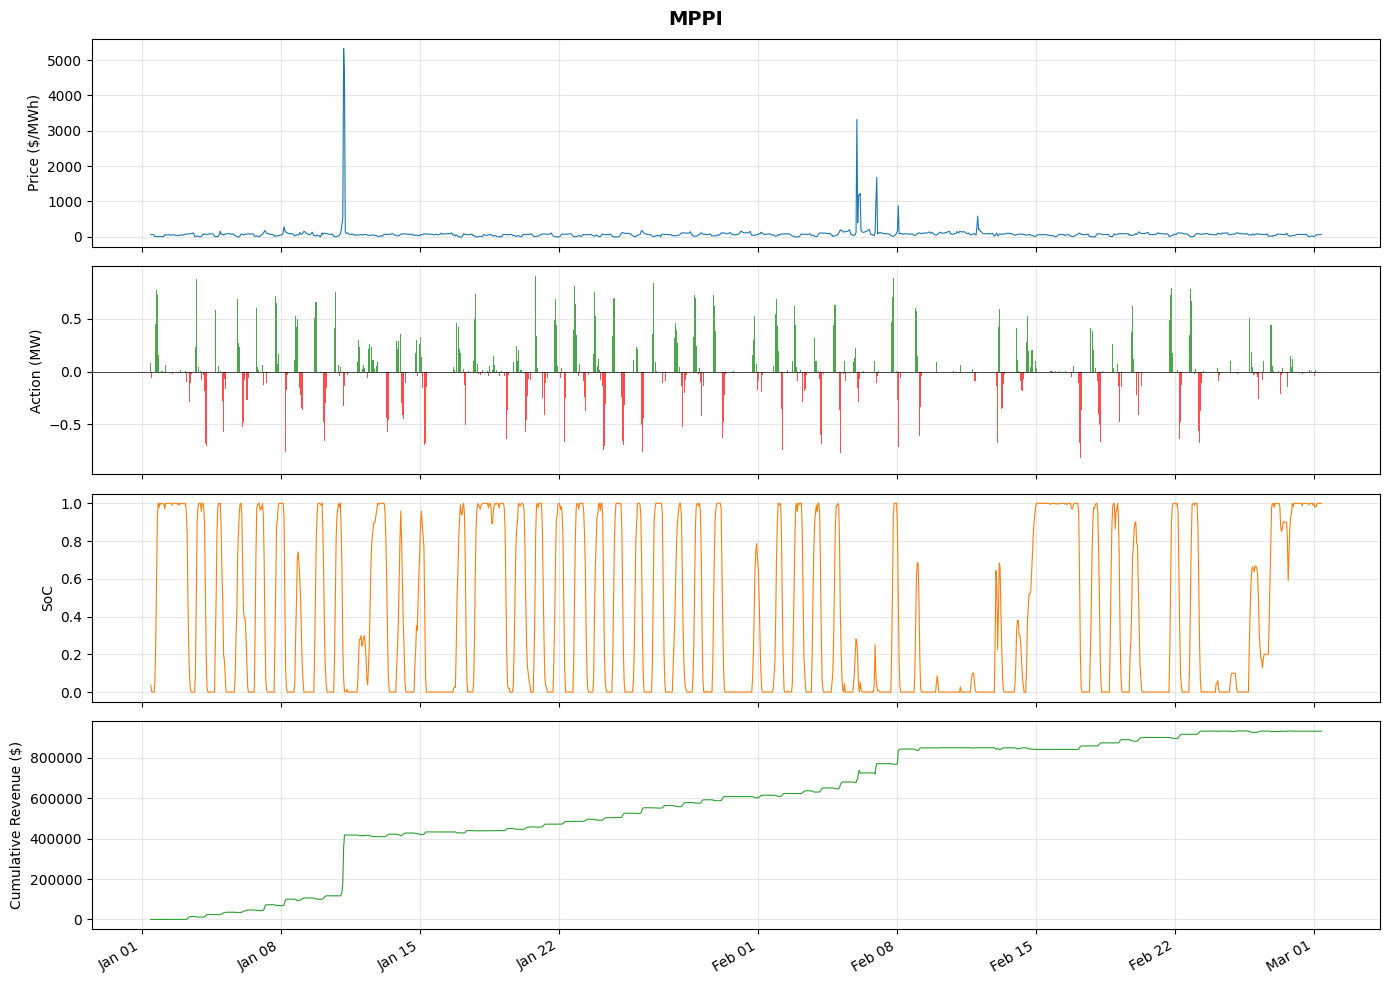

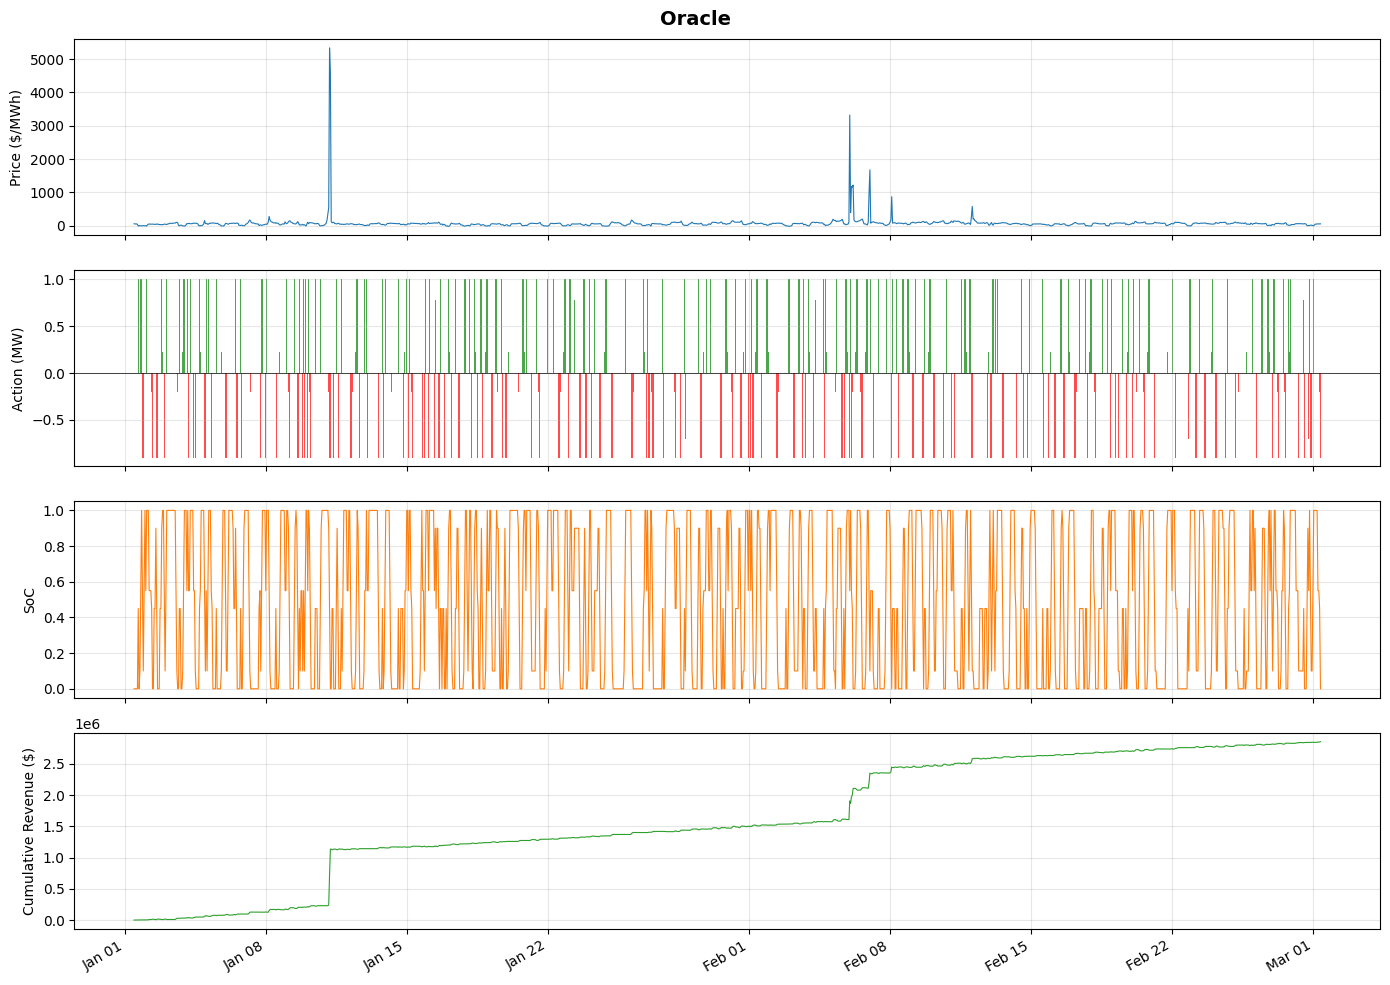

In [14]:
for e in all_evals:
    plot_eval(e)
    plt.show()

## 11. Policy Comparison

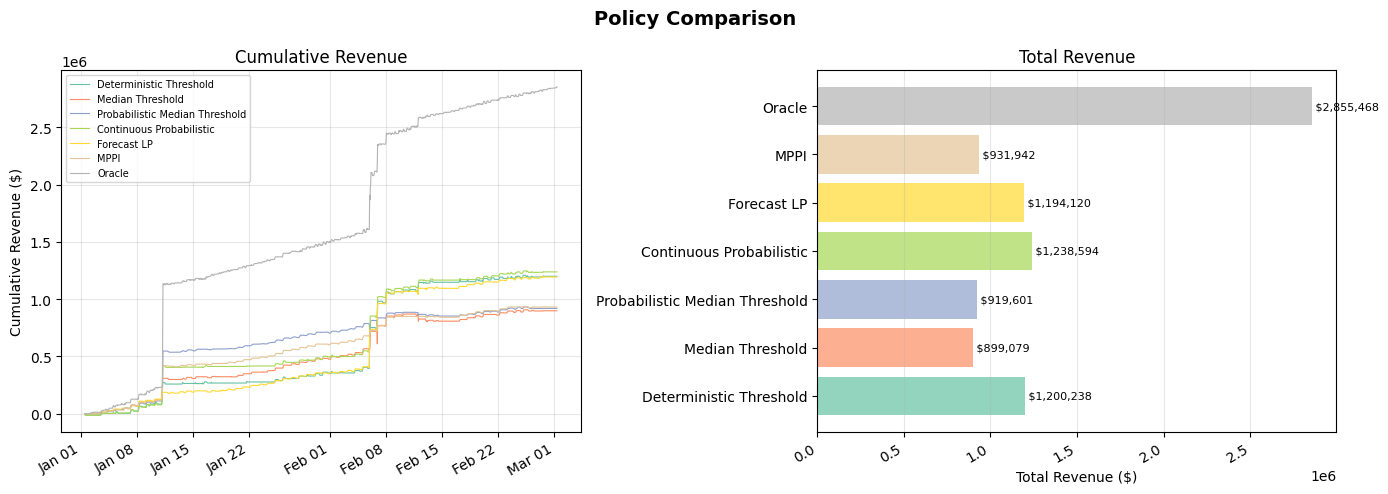

In [15]:
compare_policies(all_evals)
plt.show()